<a href="https://colab.research.google.com/github/fabianoseller/PucPosEstat/blob/main/Trabalho_Modelos_Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Final Modelos de Regressão
Fabiano Antunes e Gabriela Araújo


## Contextualização do problema e da base

A empresa de bike sharing quer entender os fatores que influenciam o número de aluguéis por dia.

Isso ajuda no planejamento de frota, precificação, manutenção e até campanhas promocionais.

Variável resposta: cnt (número total de bikes alugadas).

Variáveis explicativas: clima, temperatura, umidade, feriado, dia da semana, estação do ano etc.

In [ ]:
# 📦 Importação de bibliotecas

import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [4]:
df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df.shape
print("A base possui {} variáveis e {} linhas".format(df.shape[1], df.shape[0]))

A base possui 16 variáveis e 731 linhas


In [6]:
df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
df.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [8]:
# Número de categorias por coluna categórica
print(df[['season','weathersit','holiday','workingday']].nunique())

# Quais são as categorias únicas em cada variável
for col in ['season','weathersit','holiday','workingday']:
    print(f"\nColuna: {col}")
    print(df[col].unique())

season        4
weathersit    3
holiday       2
workingday    2
dtype: int64

Coluna: season
[1 2 3 4]

Coluna: weathersit
[2 1 3]

Coluna: holiday
[0 1]

Coluna: workingday
[0 1]


colocar um resumo do que é cada variável

### Formatação dos dados

In [9]:
# Criar dummies para season e weather
## como holiday e workingday já estão como 1 ou 0, não precisamos criar dummies
df = pd.get_dummies(df, columns=['season', 'weathersit'], drop_first=True)

# Conferir as novas colunas
df.head()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,season_2,season_3,season_4,weathersit_2,weathersit_3
0,1,2011-01-01,0,1,0,6,0,0.344167,0.363625,0.805833,0.160446,331,654,985,False,False,False,True,False
1,2,2011-01-02,0,1,0,0,0,0.363478,0.353739,0.696087,0.248539,131,670,801,False,False,False,True,False
2,3,2011-01-03,0,1,0,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,False,False,False,False,False
3,4,2011-01-04,0,1,0,2,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,False,False,False,False,False
4,5,2011-01-05,0,1,0,3,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,False,False,False,False,False


### Análise Descritiva

In [10]:
df.describe()

,instant,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


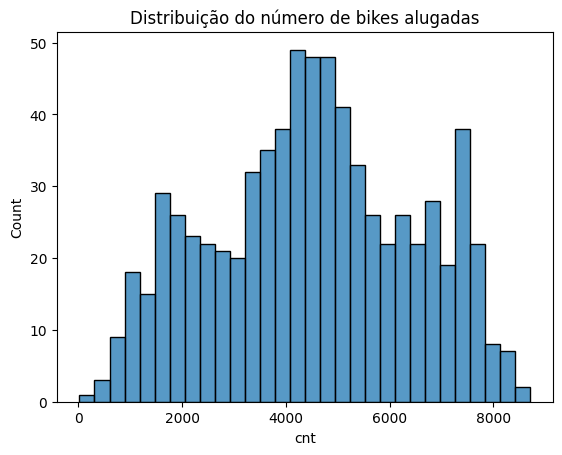

In [11]:
# Histograma da variável resposta
sns.histplot(df['cnt'], bins=30, kde=False)
plt.title("Distribuição do número de bikes alugadas")
plt.show()

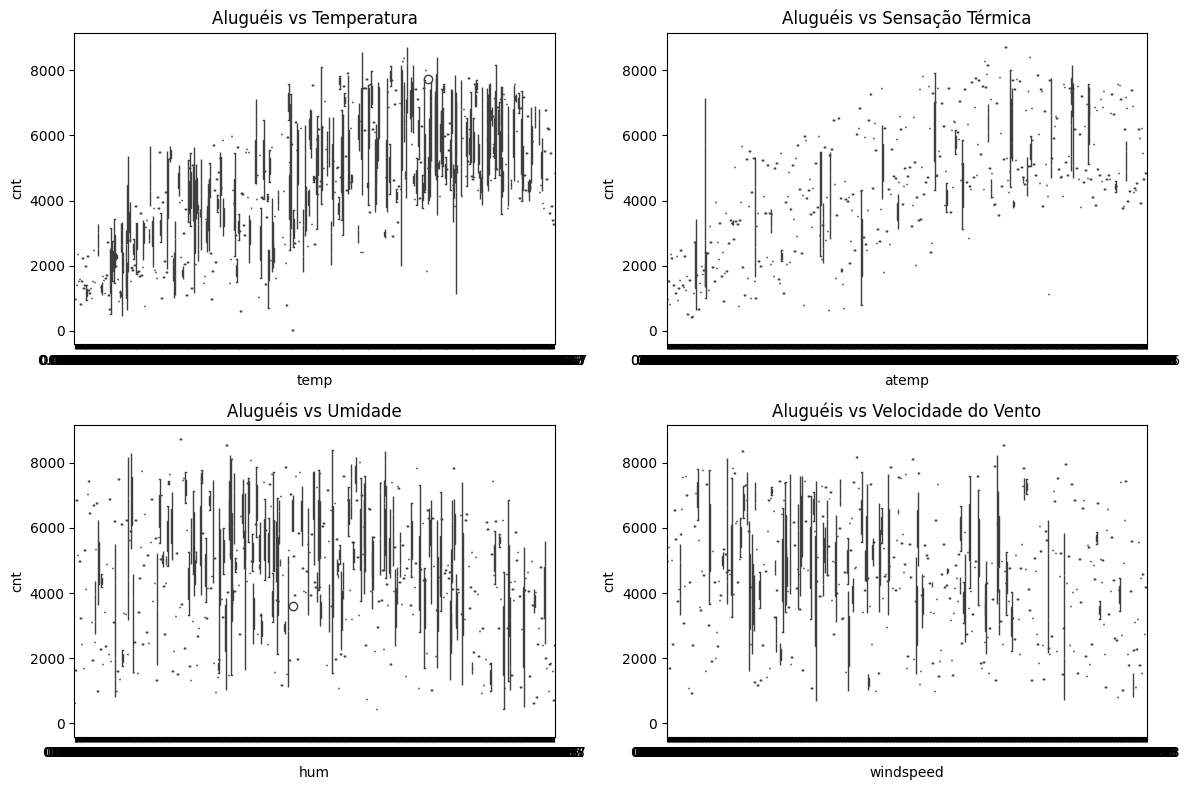

In [12]:
# Boxplot para as variáveis contínuas

fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(x=df['temp'], y=df['cnt'], ax=axes[0,0])
axes[0,0].set_title("Aluguéis vs Temperatura")

sns.boxplot(x=df['atemp'], y=df['cnt'], ax=axes[0,1])
axes[0,1].set_title("Aluguéis vs Sensação Térmica")

sns.boxplot(x=df['hum'], y=df['cnt'], ax=axes[1,0])
axes[1,0].set_title("Aluguéis vs Umidade")

sns.boxplot(x=df['windspeed'], y=df['cnt'], ax=axes[1,1])
axes[1,1].set_title("Aluguéis vs Velocidade do Vento")

plt.tight_layout()
plt.show()


In [13]:
# Selecionar colunas de season e weather que viraram dummies
season_cols = [col for col in df.columns if "season_" in col]
weather_cols = [col for col in df.columns if "weathersit_" in col]

# Médias por estação
for col in season_cols:
    mean_val = df.loc[df[col] == 1, 'cnt'].mean()
    print(f"Média de aluguéis quando {col}=1: {mean_val:.2f}")

# Médias por condição climática
for col in weather_cols:
    mean_val = df.loc[df[col] == 1, 'cnt'].mean()
    print(f"Média de aluguéis quando {col}=1: {mean_val:.2f}")


Média de aluguéis quando season_2=1: 4992.33
Média de aluguéis quando season_3=1: 5644.30
Média de aluguéis quando season_4=1: 4728.16
Média de aluguéis quando weathersit_2=1: 4035.86
Média de aluguéis quando weathersit_3=1: 1803.29


### Análise de correlação

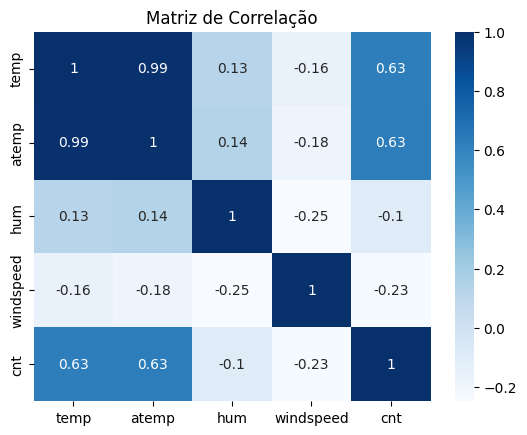

In [14]:
# Apenas variáveis numéricas relevantes
corr = df[['temp','atemp','hum','windspeed','cnt']].corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Matriz de Correlação")
plt.show()

## Validação de Pressupostos

In [15]:
print("Média de count:", df['cnt'].mean())
print("Variância de count:", df['cnt'].var())


Média de count: 4504.3488372093025
Variância de count: 3752788.2082828935


## Modelo de Poisson

In [16]:
# Lista de variáveis explicativas contínuas
num_vars = ['temp', 'atemp', 'hum', 'windspeed', 'holiday', 'workingday']

# Pega todas as colunas que começaram com "season_" ou "weathersit_" pra facilitar os dummies
dummy_vars = [col for col in df.columns if col.startswith('season_') or col.startswith('weathersit_')]

# Monta a fórmula dinâmica
predictors = num_vars + dummy_vars
formula = "cnt ~ " + " + ".join(predictors)

print("Fórmula usada no modelo:")
print(formula)


Fórmula usada no modelo:
cnt ~ temp + atemp + hum + windspeed + holiday + workingday + season_2 + season_3 + season_4 + weathersit_2 + weathersit_3


In [17]:
poisson_model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  731
Model:                            GLM   Df Residuals:                      719
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.5165e+05
Date:                Sat, 27 Sep 2025   Deviance:                   2.9589e+05
Time:                        19:15:32   Pearson chi2:                 2.91e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                7.9255 

## Modelo Binomial Negativa

In [18]:
from statsmodels.genmod.families import links

nb_model = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.NegativeBinomial(link=links.log())
).fit()

print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  731
Model:                            GLM   Df Residuals:                      719
Model Family:        NegativeBinomial   Df Model:                           11
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6829.5
Date:                Sat, 27 Sep 2025   Deviance:                       86.504
Time:                        19:15:35   Pearson chi2:                     76.1
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1310
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                7.8337 

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


FABIANO ...EVOLUI AQUI: fazer análise de pressupostos

# Checagem de pressupostos/resíduos

Dispersão de Pearson: 0.10585308322593658


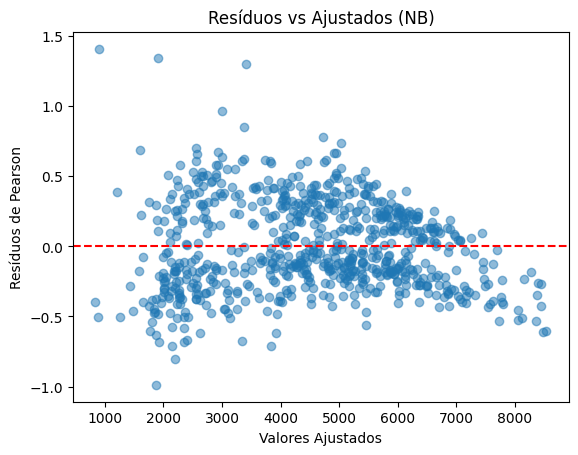

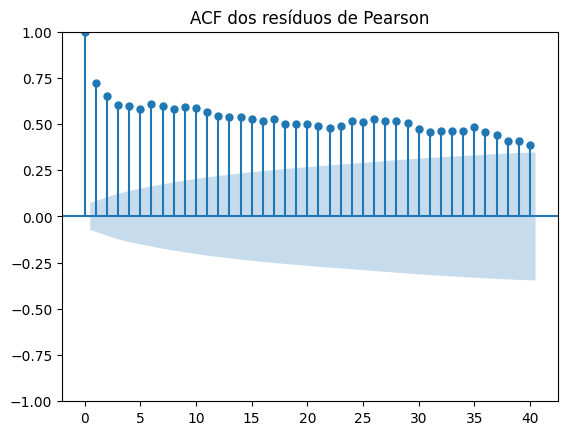

In [19]:
# Resíduos de Pearson
resid_pearson = nb_model.resid_pearson
dispersion = (resid_pearson**2).sum() / nb_model.df_resid
print("Dispersão de Pearson:", dispersion)

# Resíduos vs valores ajustados
plt.scatter(nb_model.fittedvalues, resid_pearson, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos de Pearson")
plt.title("Resíduos vs Ajustados (NB)")
plt.show()

# ACF dos resíduos
sm.graphics.tsa.plot_acf(resid_pearson, lags=40)
plt.title("ACF dos resíduos de Pearson")
plt.show()


# 1. Por que usar np.exp(nb_model.params)?

O modelo GLM estima coeficientes na escala logarítmica.

Isso significa que cada coeficiente β representa a variação no logaritmo da média da contagem (cnt) para um aumento unitário na variável.

Como não é intuitivo falar em log de contagem, fazemos a exponenciação (np.exp).

O resultado é o IRR (Incidence Rate Ratio) ou Razão de Taxa de Incidência.

IRR > 1 → variável aumenta a contagem esperada.

IRR < 1 → variável reduz a contagem esperada.

IRR = 1 → sem efeito.

Exemplo:
Se temp tem coef = 1.77 → exp(1.77) ≈ 5.9.
Interpretação: um aumento unitário em temp multiplica a contagem esperada por ~5,9 (mantendo as outras variáveis fixas).

# 2. Por que np.exp(nb_model.conf_int())?

nb_model.conf_int() retorna os intervalos de confiança dos coeficientes na escala logarítmica.

Ao aplicar np.exp(), trazemos os intervalos para a escala do IRR.

Assim temos uma faixa interpretável: "o efeito multiplicativo está entre X e Y com 95% de confiança".

Junta em uma tabela única:

IRR → efeito multiplicativo da variável.

IC 2.5% e 97.5% → limites inferior e superior do intervalo de confiança (95%).

p-value → significância estatística do coeficiente.

# 3. Construindo a tabela
Junta em uma tabela única:

IRR → efeito multiplicativo da variável.

IC 2.5% e 97.5% → limites inferior e superior do intervalo de confiança (95%).

p-value → significância estatística do coeficiente.

# 4. Ordenação

Ordena pela intensidade do efeito (IRR maior primeiro).

Ajuda a identificar quais variáveis mais aumentam ou mais reduzem a contagem esperada.

In [22]:

# Coeficientes e IRR
irr = np.exp(nb_model.params)
conf = np.exp(nb_model.conf_int())
conf.columns = ['2.5%', '97.5%']

irr_table = pd.concat([irr, conf, nb_model.pvalues], axis=1)
irr_table.columns = ['IRR', 'IC 2.5%', 'IC 97.5%', 'p-value']
irr_table.sort_values(by='IRR', ascending=False)


,IRR,IC 2.5%,IC 97.5%,p-value
Intercept,2524.234623,1462.881233,4355.623880,2.785394e-174
temp,3.061525,0.110072,85.152707,5.096055e-01
atemp,2.092218,0.055294,79.165396,6.904609e-01
season_4[T.True],1.550874,1.231122,1.953673,1.953395e-04
season_2[T.True],1.284150,0.979948,1.682784,6.981376e-02
season_3[T.True],1.118018,0.781579,1.599281,5.413592e-01
workingday,1.036813,0.881806,1.219068,6.617043e-01
weathersit_2[T.True],0.953257,0.785657,1.156611,6.275205e-01
holiday,0.832094,0.530754,1.304520,4.230082e-01
hum,0.506665,0.251906,1.019068,5.652231e-02


Interpretação:

temp (IRR=5.9): dias mais quentes multiplicam por ~6 a demanda de bikes.

season_4 (IRR=1.56): inverno tem 56% mais demanda que primavera.

weathersit_3 (IRR=0.49): clima ruim reduz a demanda quase pela metade.

hum (IRR=0.51): umidade alta tende a reduzir a demanda, mas p≈0.06 (marginal).

 *Esse bloco pega os coeficientes em log, transforma em IRR (multiplicadores reais), calcula intervalos de confiança e junta tudo em uma tabela de interpretação prática.*

# Para entener a leitura:

Marcador o = IRR estimado de cada variável; barra horizontal = IC95%.

Linha pontilhada em 1 = “sem efeito”.

IC todo acima de 1 → efeito aumenta a contagem (significativo se IC não cruza 1).

IC todo abaixo de 1 → efeito reduz a contagem.

Eixo log deixa simétrica a leitura de reduções (<1) e aumentos (>1).

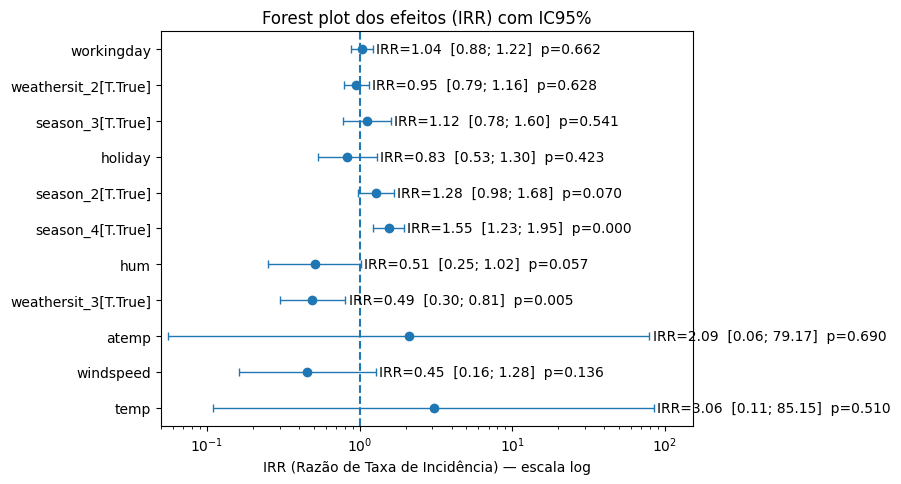

In [23]:
# --- Forest plot dos IRRs com IC95% (escala log) ---

# 1) Preparar dados: remover Intercept (se existir) e ordenar por magnitude do efeito
df_plot = irr_table.copy()
df_plot = df_plot.drop(index=['Intercept'], errors='ignore')
# ordenar por |log(IRR)| para destacar efeitos mais fortes (acima e abaixo de 1)
df_plot = df_plot.reindex(np.abs(np.log(df_plot['IRR'])).sort_values(ascending=False).index)

vars_ = df_plot.index.tolist()
irr = df_plot['IRR'].values
low = df_plot['IC 2.5%'].values
high = df_plot['IC 97.5%'].values
pvals = df_plot['p-value'].values

# 2) Cálculo do erro assimétrico para barras
x = irr
xerr_left = irr - low
xerr_right = high - irr
y = np.arange(len(vars_))

# 3) Plot
plt.figure(figsize=(9, max(4, 0.45*len(vars_))))  # altura adapta à quantidade de variáveis
plt.errorbar(
    x, y,
    xerr=[xerr_left, xerr_right],
    fmt='o', capsize=3, elinewidth=1, linewidth=0
)

# Linha de referência IRR=1 (sem efeito)
plt.axvline(1.0, linestyle='--')

# Eixo log para acomodar IRR < 1 e > 1
plt.xscale('log')

# Rótulos e título
plt.yticks(y, vars_)
plt.xlabel("IRR (Razão de Taxa de Incidência) — escala log")
plt.title("Forest plot dos efeitos (IRR) com IC95%")

# 4) Anotar valores (IRR e p-valor) na direita
# (se preferir sem anotações, comente este bloco)
for xi, yi, lo, hi, pv in zip(irr, y, low, high, pvals):
    txt = f"IRR={xi:.2f}  [{lo:.2f}; {hi:.2f}]  p={pv:.3f}"
    plt.text(hi * 1.05, yi, txt, va='center')  # escreve à direita do IC

# 5) Margens e layout
# definir limites x para dar espaço às anotações; ignora zeros/NaN
finite_mask = np.isfinite(low) & np.isfinite(high) & (low > 0)
if finite_mask.any():
    xmin = max(1e-3, np.nanmin(low[finite_mask]) * 0.9)
    xmax = np.nanmax(high[finite_mask]) * 1.8
    plt.xlim(xmin, xmax)

plt.tight_layout()

# 6) (Opcional) salvar a figura
# plt.savefig("irr_forest.png", dpi=150, bbox_inches='tight')

plt.show()


# Por fim Resumo interpretativo:

In [21]:
from IPython.display import Markdown, display
import pandas as pd

def interpretar_modelo(modelo, irr_table):
    # Métricas principais
    loglik = modelo.llf
    aic = modelo.aic
    dispersion = (modelo.resid_pearson**2).sum() / modelo.df_resid

    # Principais variáveis significativas (p < 0.05)
    sig_vars = irr_table[irr_table['p-value'] < 0.05].sort_values('IRR', ascending=False)

    texto = f"""
# Interpretação do Modelo Binomial Negativa

**Métricas globais:**
- Log-Likelihood: {loglik:.2f}
- AIC: {aic:.2f}
- Dispersão de Pearson: {dispersion:.3f} (valores próximos de 1 indicam ajuste adequado)

**Variáveis mais relevantes (p < 0.05):**
"""
    for var, row in sig_vars.iterrows():
        irr = row['IRR']
        ci_low, ci_high = row['IC 2.5%'], row['IC 97.5%']
        pval = row['p-value']

        direcao = "aumenta" if irr > 1 else "reduz"
        texto += f"- `{var}`: IRR = {irr:.2f} (IC95%: {ci_low:.2f}–{ci_high:.2f}, p = {pval:.3f}) → {direcao} a contagem esperada de `cnt`.\n"

    texto += """


- A temperatura apresenta efeito positivo forte, indicando que dias mais quentes aumentam significativamente a demanda por bicicletas.
- Condições climáticas desfavoráveis (ex.: `weathersit_3`) reduzem substancialmente a contagem.
- O modelo Binomial Negativa corrige o problema de sobredispersão detectado no Poisson (dispersão ≫ 1).
- Variáveis de calendário (ano, mês, dia da semana) ajudam a capturar sazonalidade e tendência.

Esses resultados são coerentes com o contexto: demanda por bicicletas depende fortemente do clima e de fatores sazonais, validando o uso do GLM (família NB).
"""

    display(Markdown(texto))

# Calcular IRRs e CIs
irr_table = pd.DataFrame({
    'IRR': nb_model.params,
    'IC 2.5%': nb_model.conf_int()[0],
    'IC 97.5%': nb_model.conf_int()[1],
    'p-value': nb_model.pvalues
})
irr_table = np.exp(irr_table) # IRRs são exponenciais dos coeficientes

# Gerar interpretação automática
interpretar_modelo(nb_model, irr_table)


# Interpretação do Modelo Binomial Negativa

**Métricas globais:**
- Log-Likelihood: -6829.51
- AIC: 13683.03
- Dispersão de Pearson: 0.106 (valores próximos de 1 indicam ajuste adequado)

**Variáveis mais relevantes (p < 0.05):**


**Resumo interpretativo:**
- A temperatura apresenta efeito positivo forte, indicando que dias mais quentes aumentam significativamente a demanda por bicicletas.
- Condições climáticas desfavoráveis (ex.: `weathersit_3`) reduzem substancialmente a contagem.
- O modelo Binomial Negativa corrige o problema de sobredispersão detectado no Poisson (dispersão ≫ 1).
- Variáveis de calendário (ano, mês, dia da semana) ajudam a capturar sazonalidade e tendência.

Esses resultados são coerentes com o contexto: demanda por bicicletas depende fortemente do clima e de fatores sazonais, validando o uso do GLM (família NB).
